## 1. Import Necessary Packages

In [1]:
import importlib
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import torchaudio
import numpy as np
import kaggle
import matplotlib.pyplot as plt
import pandas as pd
import librosa
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from typing import Literal

## 2. Define Default Values

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")
dataFolder = './data'
dataPath = Path(dataFolder)

Using: cuda


## 3. Download Data
In this, I will be using the [FMA Medium dataset](https://www.kaggle.com/datasets/imsparsh/fma-free-music-archive-small-medium).
Ensure that you have set your kaggle api token as an environment variable (KAGGLE_API_TOKEN) amd have enough storage for this dataset (34.26 GB).
I made this automatically check if the `./data` folder exists and skips the download if it does to prevent repeated downloadeds, to avoid this, just delete the `./data` folder when you need to redownload.

In [3]:
if not dataPath.exists():
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files('imsparsh/fma-free-music-archive-small-medium', path=dataFolder, unzip=True)

## 4. Clean and Prepare Data
Get genre names and create Dataset class to read the files. Rather than loading all 34GB into memory, this will pull the files at read time.

### Load Metadata

In [4]:
def load_fma_dataset(data_folder: str, subset: Literal['small', 'medium'] = 'medium'):
    """
    Loads FMA dataset from files to in-memory based on the subsets.

        Args:
            data_folder (string): The location that the FMA data is in
            subset ('small' | 'medium'): The dataset to be loaded

        Returns: 
            pd.DataFrame with the following columns:
                track_id - file name without the .mp3
                filepath - absolute path to the file
                genre_id - corresponding genre id from genres.csv
                split - testing, training, or validation split
                label - the output label for the genre_id
                genre_title - the full name for the genre, i.e. Electronic
    """
    genres_df = pd.read_csv(f'{data_folder}/fma_metadata/genres.csv', index_col=0)
    print(genres_df.describe)
    
    tracks_df = pd.read_csv(f'{data_folder}/fma_metadata/tracks.csv', index_col=0, header=[0, 1])

    # The FMA dataset has predetermined test/train/val splits and sizes
    subset_mask = tracks_df['set', 'subset'] == subset
    tracks_df = tracks_df[subset_mask]

    rows = []
    for track_id, row in tracks_df.iterrows():
        # file naming: folder name (3 digits) + track id (3 digits) -> unique file name (6 digits)
        id_str = str(track_id).zfill(6)
        folder = id_str[:3]
        filename = id_str + '.mp3'
        filepath = Path(data_folder) / f"fma_{subset}" / f"fma_{subset}" / folder / filename

        if not filepath.exists():
            continue
            
        genre_id = row['track', 'genre_top']
        split: Literal['training', 'validation', 'test'] = row['set', 'split']
        rows.append({
            'track_id': id_str,
            'filepath': str(filepath.resolve()),
            'genre_id': genre_id,
            'split': split
        })

    df = pd.DataFrame(rows)

    # Map genre_id to integer label [0, N)
    unique_genres = sorted(df['genre_id'].dropna().unique())
    genre_to_idx = {g: i for i, g in enumerate(unique_genres)}
    df['label'] = df['genre_id'].map(genre_to_idx)

    df['genre_title'] = df['genre_id'].map(genres_df['title'])

    return df, genre_to_idx

df, genre_map = load_fma_dataset(dataFolder)

print("Genres:")
for g, i in genre_map.items():
    print(f'{i+1}. {g}, label={i}')

<bound method NDFrame.describe of           #tracks  parent          title  top_level
genre_id                                           
1            8693      38    Avant-Garde         38
2            5271       0  International          2
3            1752       0          Blues          3
4            4126       0           Jazz          4
5            4106       0      Classical          5
...           ...     ...            ...        ...
1032           60     102        Turkish          2
1060           30      46          Tango          2
1156           26     130           Fado          2
1193           72     763      Christmas         38
1235        14938       0   Instrumental       1235

[163 rows x 4 columns]>
Genres:
1. Blues, label=0
2. Classical, label=1
3. Country, label=2
4. Easy Listening, label=3
5. Electronic, label=4
6. Experimental, label=5
7. Folk, label=6
8. Hip-Hop, label=7
9. Instrumental, label=8
10. International, label=9
11. Jazz, label=10
12. Old-Time /

### Create Custom Dataset

In [5]:
class CustomDataset(Dataset):
    def __init__(
            self, 
            df: pd.DataFrame,
            log_mels: bool,
            cqt: bool,
            sample_rate: int = 22050, 
            duration: float = 30.0, 
            n_mels: int = 128,
            n_bins: int = 84,
            bins_per_octave: int = 12,
            n_fft: int = 2048,
            hop_length: int = 512,
            cache_dir: str = None,
            transform: transforms = None,
            num_workers: int = 0
        ):
        # dataset
        self.video_labels = df['label'].to_numpy()
        self.video_paths = df['filepath'].to_numpy()
        
        self.transform = transform
        self.num_workers = num_workers

        # spectrogram values
        self.log_mels = log_mels
        self.cqt = cqt
        if not cqt and not log_mels:
            raise ValueError("log_mels or cqt must be true.")
        self.sample_rate = sample_rate
        self.duration = duration
        self.n_mels = n_mels
        self.n_bins = n_bins
        self.bins_per_octave = bins_per_octave
        self.n_fft = n_fft
        self.hop_length = hop_length

        # cache
        self.cache_dir = Path(cache_dir) if cache_dir else None
        if self.cache_dir:
            self.cache_dir.mkdir(parents=True, exist_ok=True)

        # stats
        self.lm_mean = 0.0
        self.lm_std = 0.0
        self.cqt_mean = 0.0
        self.cqt_std = 0.0

    def cache_idx(self, idx: int) -> bool:
        try:
            self.__getitem__(idx)
            return True
        except:
            return False

    def precache_all(self) -> list[str]:
        if not self.cache_dir:
            return []

        N = len(self.video_labels)
        success = [False] * N
        with ThreadPoolExecutor(max_workers=self.num_workers) as executor:
            futures = {
                executor.submit(self.cache_idx, i):i for i in range(N)
            }
            for future in tqdm(as_completed(futures), total=len(futures), desc="Caching"):
                i = futures[future]
                success[i] = future.result()
        self.video_labels = [self.video_labels[i] for i in range(N) if success[i]]
        self.video_paths = [self.video_paths[i] for i in range(N) if success[i]]
        return [i for i in range(N) if not success[i]]

    def mp3_to_log_mel(self, path: str) -> np.ndarray:
        audio, _ = librosa.load(
            path,
            sr=self.sample_rate,
            duration=self.duration,
            mono=True
        )

        # Pad clip
        expected_samples = int(self.sample_rate * self.duration)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))

        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=self.sample_rate,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Normalize to [0,1]
        log_mel = (log_mel-log_mel.min())/(log_mel.max()-log_mel.min() + 1e-8)
        return log_mel.astype(np.float32)

    def mp3_to_cqt(self, path: str) -> np.ndarray:
        audio, _ = librosa.load(
            path,
            sr=self.sample_rate,
            duration=self.duration,
            mono=True
        )

        # Pad clip
        expected_samples = int(self.duration * self.sample_rate)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))

        cqt = librosa.cqt(
            y=audio,
            sr=self.sample_rate,
            n_bins = self.n_bins,
            bins_per_octave = self.bins_per_octave,
            hop_length=self.hop_length,
            fmin=librosa.note_to_hz('C1')
        )

        # Normalize to [0,1]
        log_cqt = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)
        log_cqt = (log_cqt-log_cqt.min())/(log_cqt.max()-log_cqt.min()+1e-8)
        return log_cqt.astype(np.float32)
        

    def load_and_compute_lm(self, path: str) -> np.ndarray:
        if self.cache_dir:
            cache_path = self.cache_dir / (Path(path).stem + "_lm_.npy")
            if cache_path.exists():
                return np.load(cache_path)
        
        lm_spec = self.mp3_to_log_mel(path)

        if self.cache_dir:
            np.save(cache_path, lm_spec)

        return lm_spec
    
    def load_and_compute_cqt(self, path: str) -> np.ndarray:
        if self.cache_dir:
            cache_path = self.cache_dir / (Path(path).stem + "_cqt_.npy")
            if cache_path.exists():
                return np.load(cache_path)
        
        cqt_val = self.mp3_to_cqt(path)

        if self.cache_dir:
            np.save(cache_path, cqt_val)
        
        return cqt_val

    def __len__(self) -> int:
        return len(self.video_labels)
    
    def __getitem__(self, idx: int) -> np.ndarray:
        label = self.video_labels[idx]
        vid = self.video_paths[idx]
        
        if self.log_mels and self.cqt:
            lm_spect = self.load_and_compute_lm(vid)
            cqt_spect = self.load_and_compute_cqt(vid)

            # Get mean and std (use if dataset updated)
            self.lm_mean += lm_spect.reshape(-1).mean()
            self.lm_std += lm_spect.reshape(-1).std()
            self.cqt_mean += cqt_spect.reshape(-1).mean()
            self.cqt_std += cqt_spect.reshape(-1).std()

            cqt_spect_padded = np.pad(cqt_spect, ((0, self.n_mels - self.n_bins), (0, 0)))

            # Stack lm and cqt
            stacked_output = np.stack([lm_spect, cqt_spect_padded], axis=0)
            stacked_output = torch.tensor(stacked_output, dtype=torch.float32)
            
            if self.transform:
                stacked_output = self.transform(stacked_output)
            return stacked_output, label
        elif self.log_mels:
            lm_spect = self.load_and_compute_lm(vid)
            lm_spect = torch.tensor(lm_spect, dtype=torch.float32).unsqueeze(0)

            if self.transform:
                lm_spect = self.transform(lm_spect)
            return lm_spect, label
        else:
            cqt_spect = self.load_and_compute_cqt(vid)
            cqt_spect = torch.tensor(cqt_spect, dtype=torch.float32).unsqueeze(0)

            if self.transform:
                cqt_spect = self.transform(cqt_spect)
            return cqt_spect, label

### Load Dataset

In [6]:
# Calculated mean and std values [lm_val, cqt_val]
transform = transforms.Compose([
    transforms.Normalize(
        mean=[0.4647507724693225, 0.3520177680340939], 
        std=[0.17030458340764293, 0.29191792208277895]
    ),
    torchaudio.transforms.FrequencyMasking(freq_mask_param=15),   # mask up to 30 frequency bins
    torchaudio.transforms.TimeMasking(time_mask_param=50),        # mask up to 100 time frames
    torchaudio.transforms.TimeMasking(time_mask_param=50),        # apply twice for stronger effect

    transforms.RandomErasing(p=0.3),
])
cache = './cache/no_lyrics'
Path(cache).mkdir(exist_ok=True)

train_df = df[df['split'] == 'training'].reset_index(drop=True)
val_df = df[df['split'] == 'validation'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

train_ds = CustomDataset(train_df, True, True, cache_dir=cache, num_workers=4, transform=transform)
val_ds = CustomDataset(val_df, True, True, cache_dir=cache, num_workers=4, transform=transform)
test_ds = CustomDataset(test_df, True, True, cache_dir=cache, num_workers=4, transform=transform)

# Precaching will help to validate that all the .mp3 files are accessible.
train_ds.precache_all()
val_ds.precache_all()
test_ds.precache_all()

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

Caching:   7%|▋         | 1009/13522 [00:44<11:17, 18.48it/s]d:\anaconda3\envs\ai-genre\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Caching:  11%|█         | 1447/13522 [01:06<04:23, 45.83it/s]C:\Users\Dylan Lederman\AppData\Local\Temp\ipykernel_21468\3130097275.py:74: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
d:\anaconda3\envs\ai-genre\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Caching: 100%|██████████| 1773/1773 [01:07<00:00, 26.37it/s]


In [7]:
# Gets mean and std, not needed when already computed
print(len(train_ds))
mean = (np.array([train_ds.lm_mean, train_ds.cqt_mean]) / len(train_ds.video_paths)).tolist()
std = (np.array([train_ds.lm_std, train_ds.cqt_std]) / len(train_ds.video_paths)).tolist()
print(f"mean: {mean}, std: {std}")

13511
mean: [0.4574701189994812, 0.5119744539260864], std: [0.15959690511226654, 0.1570802927017212]


### View dataset
*Do not run if using multiple workers in DataLoader

Label: 4 — Shape: torch.Size([2, 128, 1292])


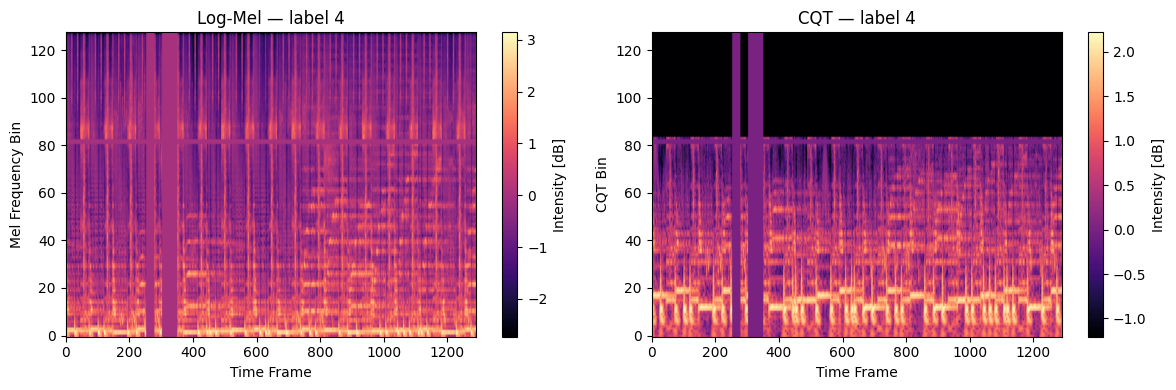

Label: 13 — Shape: torch.Size([2, 128, 1292])


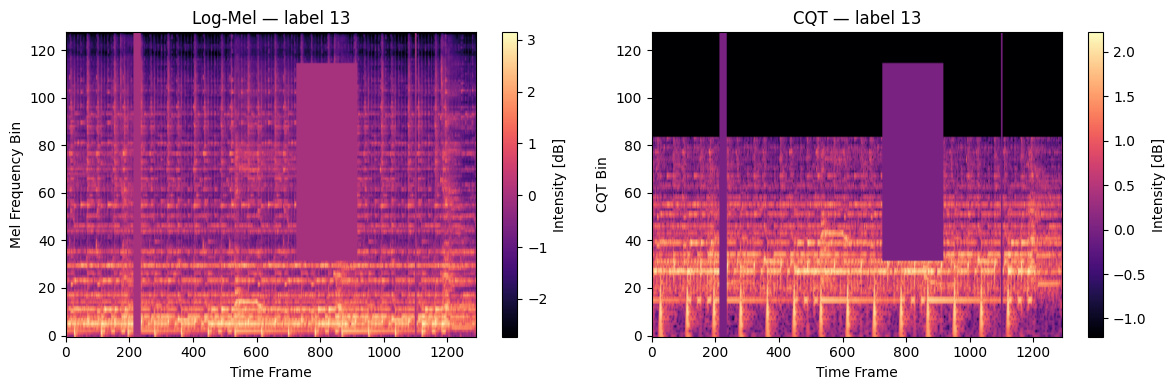

In [8]:
# These will be transformed (normalized)
def visualize_dataset(loader, ds):
    data = next(iter(loader))
    inputs, labels = data
    N = 2

    for i in range(N):
        input = inputs[i]   # (C, 128, T) where C is 1 or 2
        label = labels[i].item()
        print(f"Label: {label} — Shape: {input.shape}")

        n_channels = input.shape[0]
        fig, axes = plt.subplots(1, n_channels, figsize=(6 * n_channels, 4))

        # Ensure axes is always iterable even if n_channels == 1
        if n_channels == 1:
            axes = [axes]

        titles = []
        if ds.log_mels:
            titles.append(('Log-Mel', 'Mel Frequency Bin'))
        if ds.cqt:
            titles.append(('CQT', 'CQT Bin'))

        for ax, channel, (title, ylabel) in zip(axes, range(n_channels), titles):
            im = ax.imshow(input[channel], origin='lower', aspect='auto', cmap='magma')
            ax.set_ylabel(ylabel)
            ax.set_xlabel('Time Frame')
            ax.set_title(f'{title} — label {label}')
            fig.colorbar(im, ax=ax, label='Intensity [dB]')

        plt.tight_layout()
        plt.show()

visualize_dataset(train_loader, train_ds)

## 5. Create the Network

### Model

In [9]:
import transformer_classes
importlib.reload(transformer_classes)

<module 'transformer_classes' from 'd:\\Github\\AIGenre\\transformer_classes.py'>

## 6. Train the Network

### Testing and Accuracy Functions

In [10]:
def check_accuracy(loader: DataLoader, model: any, loss_fn: any) -> tuple[float, float, list[float], list[float], list[int]]:
    """
    Runs the given model on the given dataloader.

    Returns:
        Tuple[accuracy, loss, prediction heatmap, features, labels]
    """
    features_out = []
    def hook(model, input, output):
        features_out.append(output.detach().cpu())
    handle = model.classifier.register_forward_hook(hook)
    labels = []

    print("Checking Accuracy")
    model = model.to(device=device)
    num_correct = num_samples = 0
    model.eval()

    # NxN predicted values for heatmap
    heatmap = np.array([[0]*len(genre_map) for _ in range(len(genre_map))])

    with torch.no_grad():
        epoch_loss = 0
        for spectrogram, label in loader:
            spectrogram = spectrogram.to(device=device)
            y = label.to(device=device)

            scores = model(spectrogram)
            loss = loss_fn(scores, y)
            _, predictions = scores.max(1)
            
            heatmap[predictions.cpu(), y.cpu()] += 1
            labels.extend(label.numpy())
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)
            epoch_loss += loss.item()
        print(f"Got {num_correct} / {num_samples} with accuracy {float(num_correct)/float(num_samples)*100:.2f}%")
        print(f"Validation Loss: {float(epoch_loss)/float(len(loader)):.4f}")
    handle.remove()
    features = torch.cat(features_out, dim=0).flatten(1).numpy()
    return float(num_correct)/float(num_samples), float(epoch_loss)/float(len(loader)), heatmap, features, labels

def train_model(train_loader, valid_loader, model, optimizer, scheduler, loss_fn, epochs) -> tuple[list[float], list[float], list[float]]:
    model = model.to(device=device)
    train_accuracy = []
    losses = []
    validation_acc = []
    val_losses = []
    for e in range(epochs):
        epoch_loss = 0.0
        num_right = 0
        num_total = 0
        for spectrogram, label in tqdm(train_loader, total=len(train_loader), desc="Batch"):
            model.train()
            spectrogram = spectrogram.to(device=device)
            y = label.to(device=device)

            score = model(spectrogram)
            loss = loss_fn(score, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            

            actual = torch.argmax(score, dim=1)
            
            num_right += sum([1 if actual[i] == y[i] else 0 for i in range(len(y))])
            num_total += y.size(0)

            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)

        print(f"Epoch {e+1}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {num_right}/{num_total} ({float(num_right)/float(num_total)*100:.2f}%)")
        val_acc, val_loss, _, _, _ = check_accuracy(valid_loader, model, loss_fn)
        print()
        # Reduce on plateau requires loss/acc for which var to min/max
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        validation_acc.append(val_acc)
        losses.append(avg_loss)
        val_losses.append(val_loss)
        train_accuracy.append(float(num_right)/float(num_total))
    return train_accuracy, losses, validation_acc, val_losses

### Training
2 Phase training - Phase 1: high lr with cosine into smaller(1-e-3 -> 1e-5 5 phases (to 70%+)). Phase 2: low lr with plateau(1e-5/1e-6 (ideally to 0.9 loss (5 phases?))).

In [11]:
# Set device
model = transformer_classes.SpectrogramTransformer(len(genre_map), num_heads=8, num_layers=4).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
epochs_1 = 15
epochs_2 = 10

optimizer_1 = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler_1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_1,
    T_max=epochs_1,
    eta_min=1e-5
)
torch.cuda.empty_cache()
# Train the model
train_accuracy_1, losses_1, validation_acc_1, val_losses_1 = train_model(train_loader, val_loader, model, optimizer_1, scheduler_1, loss_fn, epochs_1,)

optimizer_2 = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-3)
scheduler_2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_2,
    mode="min",
    patience=2,
    factor=0.5,
    min_lr=1e-8
)
torch.cuda.empty_cache()
# Train the model
train_accuracy_2, losses_2, validation_acc_2, val_losses_2 = train_model(train_loader, val_loader, model, optimizer_2, scheduler_2, loss_fn, epochs_2,)



Batch: 100%|██████████| 423/423 [14:17<00:00,  2.03s/it]


Epoch 1/15, Loss: 2.2756, Accuracy: 5341/13511 (39.53%)
Checking Accuracy
Got 870 / 1704 with accuracy 51.06%
Validation Loss: 1.6530



Batch: 100%|██████████| 423/423 [14:23<00:00,  2.04s/it]


Epoch 2/15, Loss: 1.7205, Accuracy: 6207/13511 (45.94%)
Checking Accuracy
Got 860 / 1704 with accuracy 50.47%
Validation Loss: 1.5798



Batch: 100%|██████████| 423/423 [15:13<00:00,  2.16s/it]


...

Epoch 8/10, Loss: 0.9675, Accuracy: 9531/13511 (70.54%)
Checking Accuracy
Got 1201 / 1704 with accuracy 70.48%
Validation Loss: 0.9577



Batch: 100%|██████████| 423/423 [13:29<00:00,  1.91s/it]


Epoch 9/10, Loss: 0.9726, Accuracy: 9510/13511 (70.39%)
Checking Accuracy
Got 1214 / 1704 with accuracy 71.24%
Validation Loss: 0.9485



Batch: 100%|██████████| 423/423 [13:10<00:00,  1.87s/it]


Epoch 10/10, Loss: 0.9641, Accuracy: 9550/13511 (70.68%)
Checking Accuracy
Got 1218 / 1704 with accuracy 71.48%
Validation Loss: 0.9452



### Visualize Training Results

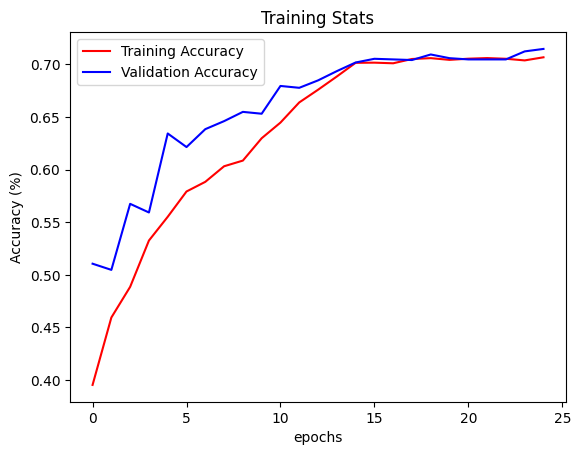

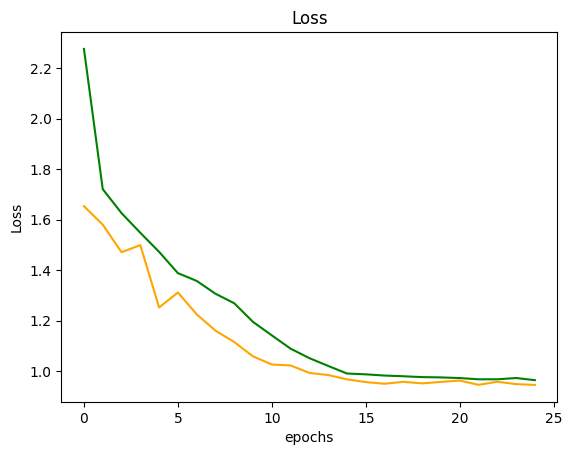

In [15]:

plt.plot(train_accuracy_1 + train_accuracy_2, label="Training Accuracy", color='red')
plt.plot(validation_acc_1 + validation_acc_2, label="Validation Accuracy", color='blue')
plt.title("Training Stats")
plt.xlabel("epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()
plt.plot(losses_1 + losses_2, label="Training Loss", color='green')
plt.plot(val_losses_1 + val_losses_2, label="Validation Loss", color='orange')
plt.title("Loss")
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.show()

## 7. Test the Network

In [16]:
train_acc, train_loss, heatmap, model_features, labels = check_accuracy(test_loader, model, loss_fn)

Checking Accuracy
Got 1204 / 1772 with accuracy 67.95%
Validation Loss: 1.1174


### Visualize the Network Learned Features

Explained variance: PC1=0.60, PC2=0.24
Total explained: 0.85


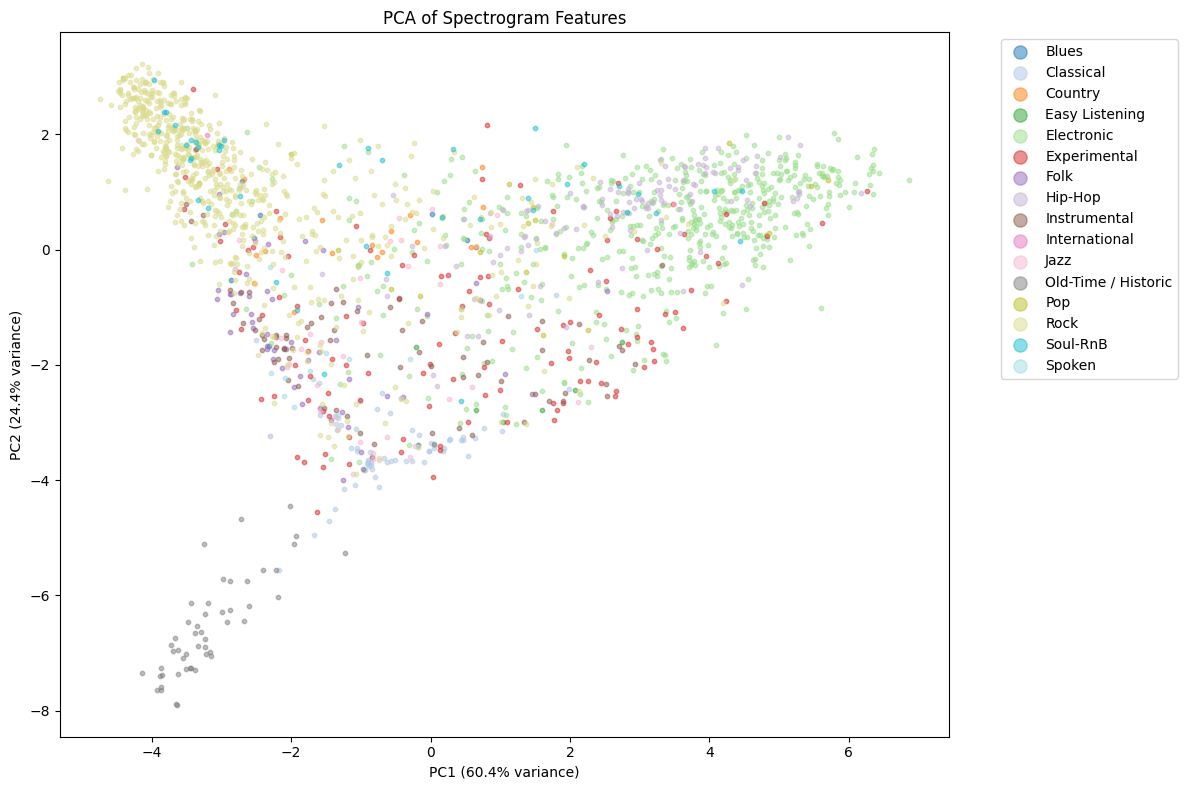

(array([[-3.193683  ,  1.3636173 ],
        [ 0.43247545, -1.1679478 ],
        [-3.3675945 ,  1.8660449 ],
        ...,
        [ 3.8690615 , -0.03686153],
        [ 5.2739744 ,  1.0075133 ],
        [ 1.4173583 , -1.12777   ]], shape=(1772, 2), dtype=float32),
 array([0.6042973 , 0.24390148], dtype=float32))

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
def plot_pca(features, labels: list[int], genre_map: dict, n_components: int = 2) -> None:
    scalar = StandardScaler()
    features = scalar.fit_transform(features)

    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(features)
    explained = pca.explained_variance_ratio_

    print(f"Explained variance: PC1={explained[0]:.2f}, PC2={explained[1]:.2f}")
    print(f"Total explained: {explained.sum():.2f}")

    idx_to_genre = {v: k for k, v in genre_map.items()}
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

    fig, ax = plt.subplots(figsize=(12, 8))
    for label, color in zip(unique_labels, colors):
        mask = labels == label
        ax.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            label=idx_to_genre.get(label, str(label)),
            alpha=0.5,
            s=10,
            color=color
        )

    ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
    ax.set_title("PCA of Spectrogram Features")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3)
    plt.tight_layout()
    plt.show()

    return reduced, explained

plot_pca(model_features, labels, genre_map)

### Confusion Matrix

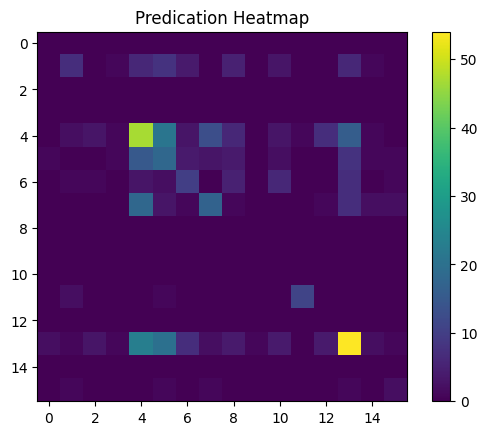

In [18]:
plt.imshow(heatmap, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('Predication Heatmap')
plt.show()